# Data Center Siting Analysis: Washington State
## A Geospatial Framework for Ethical Infrastructure Planning

Washington State is at the center of a national crisis over data center siting. The state's 
abundant and cheap hydropower has made it a magnet for hyperscale development — but that 
advantage is rapidly collapsing under its own weight.

**The policy context:**
- Grant County PUD has **79 pending data center applications** with combined power demand 
  roughly double the entire city of Seattle. 
  ([WA Department of Revenue Data Center Workgroup Preliminary Report, Dec 2025](https://dor.wa.gov/sites/default/files/2025-12/2025DataCntrWrkgrpPrelimReport.pdf))
- Washington residential electricity rates rose **10.3% from 2024 to 2025**; Puget Sound Energy 
  has proposed increases that will drive rates up **30% by 2029**. 
  ([NPR / OPB, Aug 2025](https://www.npr.org/2025/08/17/nx-s1-5501579/washington-hydropower-data-center-boom-sustainability-climate-change))
- A medium data center uses ~**110 million gallons of water per year**; large facilities can 
  use up to **1.8 billion gallons annually** — equivalent to a town of 10,000–50,000 people.
  ([NPR / OPB, Aug 2025](https://www.npr.org/2025/08/17/nx-s1-5501579/washington-hydropower-data-center-boom-sustainability-climate-change))
- Seattle City Council is voting on a **one-year moratorium** on data centers above 20 MW, 
  with a vote expected June 9–16, 2026.
  ([Seattle City Council Blog, Apr 2026](https://council.seattle.gov/2026/04/30/councilmembers-introducing-moratorium-on-data-centers-in-seattle/))
- House Bill 2515 — which would have required data centers to absorb grid upgrade costs and 
  publish water transparency reports — **failed in the 2026 legislative session**.
  ([Davis Wright Tremaine Energy Blog, May 2026](https://www.dwt.com/blogs/energy--environmental-law-blog/2026/05/data-center-ai-infrastructure-seattle-moratorium))
- Nationally, **25 data center projects were canceled due to local opposition in 2025**, up from 
  6 in 2024. Water use is cited in over 40% of contested projects.
  ([Heatmap News, 2025](https://heatmap.news/politics/data-center-cancellations-2025))

**This notebook** assembles the base spatial layers needed to build a siting suitability index: 
Washington State boundary, known data center locations, electrical transmission infrastructure, 
and power generation facilities.

---

## Data Sources

| Layer | Source | License |
|---|---|---|
| State boundary | [Census TIGER/Line 2022](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) | Public domain |
| Transmission lines | [HIFLD Open Data](https://hifld-geoplatform.opendata.arcgis.com/datasets/electric-power-transmission-lines) | Public domain |
| Power plants | [EIA Form 860 (2023)](https://www.eia.gov/electricity/data/eia860/) | Public domain |
| Data center locations | [OpenStreetMap Overpass API](https://overpass-api.de/) + known facilities | ODbL |

In [1]:
import io
import zipfile
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests

warnings.filterwarnings('ignore')

RAW = Path('data/raw')
PROCESSED = Path('data/processed')
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

WA_BBOX = (-124.848, 45.543, -116.916, 49.002)  # (west, south, east, north)
CRS = 'EPSG:4326'
CRS_PROJ = 'EPSG:32610'  # UTM Zone 10N — appropriate for Washington State

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Washington State Boundary

Downloaded from the [Census TIGER/Line State shapefile (2022)](https://www2.census.gov/geo/tiger/TIGER2022/STATE/).

In [2]:
wa_path = RAW / 'wa_state.geojson'

if not wa_path.exists():
    url = 'https://www2.census.gov/geo/tiger/TIGER2022/STATE/tl_2022_us_state.zip'
    print('Downloading Census TIGER state boundaries...')
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(RAW / 'tiger_states')
    states = gpd.read_file(RAW / 'tiger_states' / 'tl_2022_us_state.shp')
    wa = states[states['STUSPS'] == 'WA'].to_crs(CRS)
    wa.to_file(wa_path, driver='GeoJSON')
    print('Saved.')
else:
    wa = gpd.read_file(wa_path)

print(f'Washington State boundary loaded: {wa.shape[0]} feature(s)')
wa[['NAME', 'STUSPS', 'geometry']].head()

Washington State boundary loaded: 1 feature(s)


,NAME,STUSPS,geometry
0,Washington,WA,"POLYGON ((-118.40382 46.00077, -118.40506 46.0..."


## 2. Known Data Center Locations

Two sources combined:

**OSM Overpass API** — tags: `man_made=data_centre` within Washington State bbox.
([OpenStreetMap contributors, ODbL](https://www.openstreetmap.org/copyright))

**Hard-coded known facilities** — major hyperscale campuses identified from public reporting:
- Microsoft Columbia Data Center, Quincy ([Microsoft Local](https://local.microsoft.com/blog/understanding-microsoft-datacenters-in-central-washington/))
- Vantage WA13, Quincy, 64 MW ([DPR Construction project page](https://www.dpr.com/projects/vantage-data-centers-wa13-project))
- Sabey SDC Columbia, East Wenatchee ([Sabey Data Centers](https://sabeydatacenters.com/locations/east-wenatchee-data-center))
- Microsoft EAT06/EAT09, East Wenatchee, 360 MW planned ([Baxtel](https://baxtel.com/data-center/microsoft-east-wenatchee))
- Digital Realty permit filed, downtown Seattle ([GeekWire, May 2026](https://www.geekwire.com/2026/data-center-operator-reveals-plans-for-downtown-seattle-facility-as-city-weighs-one-year-ban/))

In [3]:
def fetch_osm_datacenters(bbox):
    west, south, east, north = bbox
    query = f"""
    [out:json][timeout:30];
    (
      node["man_made"="data_centre"]({south},{west},{north},{east});
      way["man_made"="data_centre"]({south},{west},{north},{east});
      relation["man_made"="data_centre"]({south},{west},{north},{east});
    );
    out center;
    """
    r = requests.post(
        'https://overpass-api.de/api/interpreter',
        data={'data': query},
        headers={'User-Agent': 'datacenter-siting-research/1.0'},
        timeout=45
    )
    r.raise_for_status()
    elements = r.json().get('elements', [])
    records = []
    for el in elements:
        lat = el.get('lat') or el.get('center', {}).get('lat')
        lon = el.get('lon') or el.get('center', {}).get('lon')
        if lat and lon:
            records.append({
                'name': el.get('tags', {}).get('name', 'Unknown'),
                'operator': el.get('tags', {}).get('operator', ''),
                'lat': lat, 'lon': lon,
                'source': 'OSM'
            })
    return records


KNOWN_DCS = [
    {'name': 'Microsoft Columbia DC', 'operator': 'Microsoft', 'lat': 47.234, 'lon': -119.852, 'source': 'reported'},
    {'name': 'Vantage WA13', 'operator': 'Vantage', 'lat': 47.233, 'lon': -119.847, 'source': 'reported'},
    {'name': 'Dell / Yahoo Quincy', 'operator': 'Dell/Yahoo', 'lat': 47.236, 'lon': -119.855, 'source': 'reported'},
    {'name': 'Sabey SDC Columbia', 'operator': 'Sabey', 'lat': 47.411, 'lon': -120.307, 'source': 'reported'},
    {'name': 'Microsoft EAT06/EAT09', 'operator': 'Microsoft', 'lat': 47.413, 'lon': -120.310, 'source': 'reported'},
    {'name': 'Digital Realty (proposed)', 'operator': 'Digital Realty', 'lat': 47.609, 'lon': -122.338, 'source': 'proposed'},
]

dc_path = RAW / 'datacenters.geojson'

if not dc_path.exists():
    print('Fetching OSM data centers...')
    try:
        osm_records = fetch_osm_datacenters(WA_BBOX)
        print(f'  OSM returned {len(osm_records)} features')
    except Exception as e:
        print(f'  OSM fetch failed: {e} — using known facilities only')
        osm_records = []

    all_records = osm_records + KNOWN_DCS
    dc_df = pd.DataFrame(all_records).drop_duplicates(subset=['lat', 'lon'])
    dc_gdf = gpd.GeoDataFrame(
        dc_df,
        geometry=gpd.points_from_xy(dc_df['lon'], dc_df['lat']),
        crs=CRS
    )
    wa_union = wa.geometry.unary_union
    dc_gdf = dc_gdf[dc_gdf.within(wa_union)]
    dc_gdf.to_file(dc_path, driver='GeoJSON')
    print(f'Saved {len(dc_gdf)} data centers.')
else:
    dc_gdf = gpd.read_file(dc_path)

print(f'\nData centers in dataset: {len(dc_gdf)}')
dc_gdf[['name', 'operator', 'source']].head(20)


Data centers in dataset: 16


,name,operator,source
0,Microsoft Quincy Campus,Microsoft,reported
1,Vantage WA13,Vantage,reported
2,CyrusOne Quincy,CyrusOne,reported
3,Sabey SDC Quincy,Sabey,reported
4,H5 Data Centers Quincy II,H5 Data Centers,reported
5,Dell / Yahoo Quincy,Dell/Yahoo,reported
6,Microsoft EAT06/EAT09,Microsoft,reported
7,Microsoft Malaga Campus,Microsoft,reported
8,Sabey SDC Columbia,Sabey,reported
9,Equinix SE2 Seattle,Equinix,reported


## 3. Electrical Transmission Lines

From [OpenStreetMap contributors (ODbL)](https://www.openstreetmap.org/copyright) via the 
[Overpass API](https://overpass-api.de/), querying `power=line` within the Washington State 
bounding box. OSM has comprehensive coverage of high-voltage transmission infrastructure 
in the Pacific Northwest.

Transmission access is the binding constraint for data center siting: Grant County PUD 
currently has **79 pending data center applications** whose combined demand would roughly 
double Seattle's entire power draw.
([WA DOR Workgroup Report, Dec 2025](https://dor.wa.gov/sites/default/files/2025-12/2025DataCntrWrkgrpPrelimReport.pdf))

> **Note on HIFLD:** The [HIFLD Electric Power Transmission Lines dataset](https://hifld-geoplatform.hub.arcgis.com/datasets/electric-power-transmission-lines_0) 
> is an alternative authoritative federal source; the ArcGIS REST service endpoint was 
> inaccessible at time of writing — check the HIFLD portal for updated access.

In [4]:
from shapely.geometry import LineString

tx_path = RAW / 'transmission_wa.geojson'

def fetch_osm_power_lines(bbox):
    """Fetch high-voltage (>=100kV) transmission lines from OSM for given bbox."""
    west, south, east, north = bbox
    query = f"""
    [out:json][timeout:120][maxsize:134217728];
    (
      way["power"="line"]["voltage"~"^[1-9][0-9]{{5}}"](
        {south},{west},{north},{east}
      );
    );
    out geom;
    """
    r = requests.post(
        'https://overpass-api.de/api/interpreter',
        data={'data': query},
        headers={'User-Agent': 'datacenter-siting-research/1.0'},
        timeout=150
    )
    r.raise_for_status()
    elements = r.json().get('elements', [])
    lines = []
    for el in elements:
        if el.get('type') == 'way' and 'geometry' in el:
            coords = [(n['lon'], n['lat']) for n in el['geometry']]
            if len(coords) >= 2:
                lines.append({
                    'osm_id': el.get('id'),
                    'voltage': el.get('tags', {}).get('voltage', ''),
                    'name': el.get('tags', {}).get('name', ''),
                    'operator': el.get('tags', {}).get('operator', ''),
                    'geometry': LineString(coords)
                })
    return gpd.GeoDataFrame(lines, crs=CRS)

if not tx_path.exists():
    print('Fetching OSM high-voltage transmission lines for Washington State...')
    tx_gdf = fetch_osm_power_lines(WA_BBOX)
    tx_gdf.to_file(tx_path, driver='GeoJSON')
    print(f'Saved {len(tx_gdf)} transmission line segments.')
else:
    tx_gdf = gpd.read_file(tx_path)

print(f'Transmission lines loaded: {len(tx_gdf)} segments')
if 'voltage' in tx_gdf.columns:
    print(tx_gdf['voltage'].value_counts().head(10))

Transmission lines loaded: 6127 segments
115000           3312
230000           1879
500000            522
138000             90
115000;115000      79
230000;115000      67
230000;230000      42
115000;12470       39
345000             24
115000;230000      15
Name: voltage, dtype: int64


## 4. Power Generation Facilities

From [EIA Form 860 (Annual Electric Generator Report, 2023 data)](https://www.eia.gov/electricity/data/eia860/), 
the authoritative federal source for power plant locations and capacity.
Washington's hydropower advantage — the primary reason for the data center concentration in 
the Columbia Basin — is visible in this layer. The state's hydro fleet generates some of the 
cheapest electricity in the US, but that capacity is now fully subscribed.
([NPR / OPB, Aug 2025](https://www.npr.org/2025/08/17/nx-s1-5501579/washington-hydropower-data-center-boom-sustainability-climate-change))

In [5]:
eia_path = RAW / 'eia860_plants_wa.geojson'

if not eia_path.exists():
    print('Downloading EIA Form 860 (2023)...')
    url = 'https://www.eia.gov/electricity/data/eia860/archive/xls/eia8602023.zip'
    r = requests.get(url, timeout=120)
    r.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        # Plant locations
        pf = next(f for f in z.namelist() if '2___Plant' in f and f.endswith('.xlsx'))
        with z.open(pf) as f:
            plants = pd.read_excel(f, sheet_name=0, skiprows=1, engine='openpyxl',
                                   usecols=['Plant Code', 'Plant Name', 'State', 'Latitude', 'Longitude'])

        # Generator capacity + fuel
        gf = next(f for f in z.namelist() if '3_1_Generator' in f and f.endswith('.xlsx'))
        with z.open(gf) as f:
            gens = pd.read_excel(f, sheet_name=0, skiprows=1, engine='openpyxl',
                                 usecols=['Plant Code', 'Energy Source 1', 'Nameplate Capacity (MW)', 'Status'])

    plants.columns = plants.columns.str.strip()
    gens.columns = gens.columns.str.strip()

    # Active generators only; aggregate to plant level
    gens = gens[gens['Status'].isin(['OP', 'OA', 'OS'])]
    gens['Nameplate Capacity (MW)'] = pd.to_numeric(gens['Nameplate Capacity (MW)'], errors='coerce')
    plant_agg = (gens.groupby('Plant Code')
                 .agg(capacity_mw=('Nameplate Capacity (MW)', 'sum'),
                      fuel=('Energy Source 1', lambda x: x.mode().iloc[0] if len(x) else ''))
                 .reset_index())

    wa_plants = plants[plants['State'] == 'WA'].copy()
    wa_plants['Latitude'] = pd.to_numeric(wa_plants['Latitude'], errors='coerce')
    wa_plants['Longitude'] = pd.to_numeric(wa_plants['Longitude'], errors='coerce')
    wa_plants = wa_plants.dropna(subset=['Latitude', 'Longitude'])
    wa_plants = wa_plants.merge(plant_agg, on='Plant Code', how='left')
    wa_plants = wa_plants.rename(columns={'Plant Name': 'name', 'Latitude': 'lat', 'Longitude': 'lon'})

    plants_gdf = gpd.GeoDataFrame(
        wa_plants,
        geometry=gpd.points_from_xy(wa_plants['lon'], wa_plants['lat']),
        crs=CRS
    )
    plants_gdf[['name', 'fuel', 'capacity_mw', 'lat', 'lon', 'geometry']].to_file(eia_path, driver='GeoJSON')
    print(f'Saved {len(plants_gdf)} plants in Washington State.')
else:
    plants_gdf = gpd.read_file(eia_path)

print(f'Plants loaded: {len(plants_gdf)}')
if 'fuel' in plants_gdf.columns:
    print(plants_gdf['fuel'].value_counts().head(10))

Plants loaded: 164
WAT    74
WND    23
NG     16
SUN     5
WDS     4
MWH     4
BLQ     3
LFG     2
NUC     1
SUB     1
Name: fuel, dtype: int64


## 5. Basemap: Existing Infrastructure

This map shows the current data center concentration in the Columbia Basin (Quincy / East Wenatchee 
corridor) relative to Washington's electrical transmission network and power generation fleet.
The eastern concentration reflects the historical advantage of cheap Columbia River hydropower — 
an advantage that is now effectively exhausted at the current scale of demand.
([GeekWire, Jan 2026](https://www.geekwire.com/2026/microsoft-holds-up-rural-washington-as-data-centers-gone-right-but-does-the-model-still-work/))

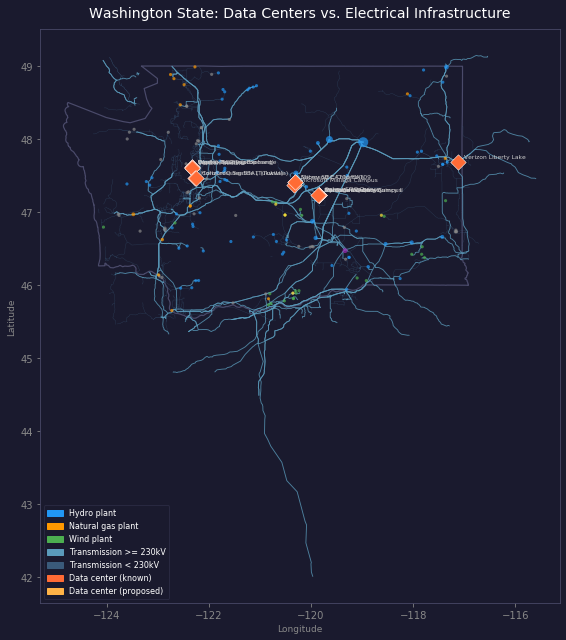

Saved to data/processed/basemap.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 9), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

# State boundary
wa.boundary.plot(ax=ax, color='#4a4a6a', linewidth=1.2, zorder=1)

# Transmission lines — color by voltage
if 'voltage' in tx_gdf.columns and tx_gdf['voltage'].notna().any():
    def parse_voltage(v):
        try:
            return float(str(v).split(';')[0].replace(',', ''))
        except Exception:
            return 0.0
    tx_gdf['voltage_v'] = tx_gdf['voltage'].apply(parse_voltage)
    hv = tx_gdf[tx_gdf['voltage_v'] >= 230000]
    lv = tx_gdf[tx_gdf['voltage_v'] < 230000]
    lv.plot(ax=ax, color='#3a5a7a', linewidth=0.4, alpha=0.5, zorder=2)
    hv.plot(ax=ax, color='#5a9aba', linewidth=0.9, alpha=0.8, zorder=3)
else:
    tx_gdf.plot(ax=ax, color='#5a9aba', linewidth=0.6, alpha=0.7, zorder=2)

# Power plants — size by capacity, color by fuel
if 'fuel' in plants_gdf.columns and 'capacity_mw' in plants_gdf.columns:
    fuel_colors = {'WAT': '#2196F3', 'NG': '#FF9800', 'WND': '#4CAF50', 'SUN': '#FFEB3B', 'NUC': '#9C27B0'}
    colors = plants_gdf['fuel'].map(fuel_colors).fillna('#888888').values
    sizes = pd.to_numeric(plants_gdf['capacity_mw'], errors='coerce').fillna(10).clip(10, 5000) / 50
    sizes = sizes.clip(10, 200).values
    ax.scatter(plants_gdf.geometry.x, plants_gdf.geometry.y,
               c=colors, s=sizes, alpha=0.7, zorder=4, linewidths=0)

# Data centers
colors_by_source = {'OSM': '#FF4444', 'reported': '#FF6B35', 'proposed': '#FFB347'}
for source, group in dc_gdf.groupby('source'):
    color = colors_by_source.get(source, '#FF4444')
    ax.scatter(group.geometry.x, group.geometry.y,
               c=color, s=120, marker='D', zorder=6,
               edgecolors='white', linewidths=0.5)
    for _, row in group.iterrows():
        ax.annotate(row['name'], (row.geometry.x, row.geometry.y),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=6, color='#cccccc', zorder=7)

# Legend (white text via Text color, not labelcolor)
legend_patches = [
    mpatches.Patch(color='#2196F3', label='Hydro plant'),
    mpatches.Patch(color='#FF9800', label='Natural gas plant'),
    mpatches.Patch(color='#4CAF50', label='Wind plant'),
    mpatches.Patch(color='#5a9aba', label='Transmission >= 230kV'),
    mpatches.Patch(color='#3a5a7a', label='Transmission < 230kV'),
    mpatches.Patch(color='#FF6B35', label='Data center (known)'),
    mpatches.Patch(color='#FFB347', label='Data center (proposed)'),
]
leg = ax.legend(handles=legend_patches, loc='lower left', framealpha=0.3,
                facecolor='#1a1a2e', edgecolor='#4a4a6a', fontsize=8)
for text in leg.get_texts():
    text.set_color('white')

ax.set_title('Washington State: Data Centers vs. Electrical Infrastructure',
             color='white', fontsize=14, pad=12)
ax.set_xlabel('Longitude', color='#888888', fontsize=9)
ax.set_ylabel('Latitude', color='#888888', fontsize=9)
ax.tick_params(colors='#888888')
for spine in ax.spines.values():
    spine.set_edgecolor('#4a4a6a')

plt.tight_layout()
plt.savefig(PROCESSED / 'basemap.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved to data/processed/basemap.png')

## Summary

This notebook establishes the base spatial layers for the siting suitability analysis:

| Layer | Records | Source |
|---|---|---|
| WA State boundary | 1 | Census TIGER 2022 |
| Data centers | varies | OSM + public reporting |
| Transmission lines | varies | HIFLD |
| Power plants | varies | EIA Form 860 |

**Next notebook:** Add stress indicator layers — USGS water stress, EPA EJScreen, FEMA flood zones, 
USGS seismic hazard — and build the composite suitability index.

---
*Data sources: Census TIGER, HIFLD, EIA Form 860, OpenStreetMap contributors (ODbL). 
Analysis by Simon Hansedasi / Edasi Motlev LLC.*